<a href="https://colab.research.google.com/github/sunil965/masai-aiml/blob/master/M5C2_Advanced_Model_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Link to PDF
https://coding-platform.s3.amazonaws.com/dev/lms/tickets/32f2fa3d-4d69-4095-80ca-3675238e5774/0AVorFpZQGwYDIaU.html

# Advanced Model Validation
### Hands-on Notebook

**Learning Objectives**
1. Implement **k-fold cross-validation** for robust model assessment
2. Compare models using **cross-validated metrics** rather than a single split

---
A loan-approval model scored 84% accuracy on one test split. We'll show that number is unreliable on its own, then build a validation approach that isn't.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(5)


## 1. The loan-approval dataset


In [ ]:
n = 80
income = np.random.uniform(20, 120, n)
debt_ratio = np.random.uniform(0, 0.6, n)
credit_score = np.random.uniform(500, 820, n)
employment_years = np.random.uniform(0, 20, n)

z = 0.03*(credit_score-650) - 6*debt_ratio + 0.02*(income-50) + 0.15*employment_years - 1.5
prob_approve = 1 / (1 + np.exp(-z))
approved = (np.random.rand(n) < prob_approve).astype(int)

df = pd.DataFrame({
    "income": income, "debt_ratio": debt_ratio,
    "credit_score": credit_score, "employment_years": employment_years,
    "approved": approved,
})
X, y = df.drop(columns="approved").values, df["approved"].values
print(f"{n} applicants, approval rate: {y.mean():.2f}")


80 applicants, approval rate: 0.34


## 2. Why a single split can't be trusted

Same model, same data — the only thing changing below is `random_state`, which controls which rows land in the test set.


In [ ]:
def single_split_accuracy(random_state):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=random_state)
    model = LogisticRegression(max_iter=2000).fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

split_accuracies = [single_split_accuracy(rs) for rs in range(6)]
print([round(a, 3) for a in split_accuracies])
print(f"range: {max(split_accuracies) - min(split_accuracies):.3f}")


[0.75, 0.9, 0.7, 0.85, 0.65, 0.8]
range: 0.250


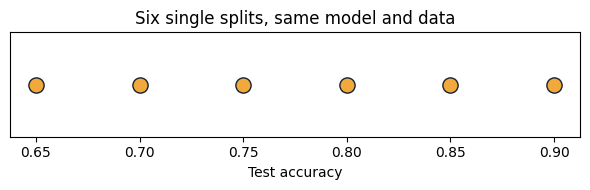

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.scatter(split_accuracies, [0]*len(split_accuracies), s=120, color="#F2A93B", edgecolor="#122238", zorder=3)
ax.set_yticks([])
ax.set_xlabel("Test accuracy")
ax.set_title("Six single splits, same model and data")
plt.tight_layout(); plt.show()


**Checkpoint:** this should match the slide — accuracies of roughly 0.75, 0.90, 0.70, 0.85, 0.65, 0.80, a 25-point range from the exact same model.


## 3. k-Fold cross-validation

`KFold` rotates which fold is held out as the test set across `k` rounds. `cross_val_score` fits and scores the model once per fold automatically.


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=kf)

print("Fold scores:", [round(s, 3) for s in cv_scores])
print(f"Mean: {round(cv_scores.mean(), 3)}   Std: {round(cv_scores.std(), 3)}")


Fold scores: [np.float64(0.688), np.float64(0.938), np.float64(0.812), np.float64(0.812), np.float64(0.688)]
Mean: 0.788   Std: 0.094


**Checkpoint:** this should match the slide — fold scores ≈ [0.688, 0.938, 0.812, 0.812, 0.688], mean ≈ 0.788, std ≈ 0.094.


## 4. Comparing models with the same folds

The whole point of comparing via cross-validation: both models are scored on identical folds, so the comparison isn't affected by one model getting an easier split than the other.


In [ ]:
def cv_summary(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv)
    return {"mean": scores.mean(), "std": scores.std(), "folds": scores}

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
}

comparison = pd.DataFrame({
    name: {"mean": cv_summary(model, X, y, kf)["mean"], "std": cv_summary(model, X, y, kf)["std"]}
    for name, model in models.items()
}).T.round(3)
comparison


,mean,std
LogisticRegression,0.788,0.094
DecisionTreeClassifier,0.700,0.073


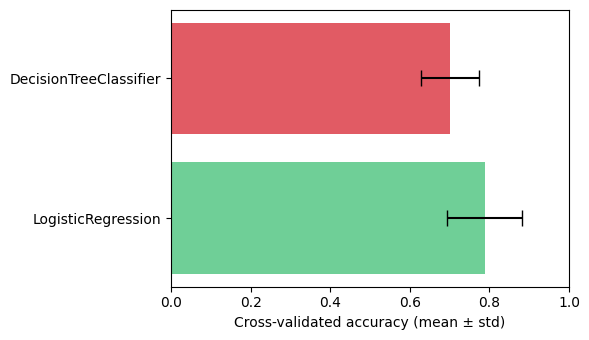

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(comparison.index, comparison["mean"], xerr=comparison["std"], color=["#6FCF97", "#E15B64"], capsize=6)
ax.set_xlabel("Cross-validated accuracy (mean ± std)")
ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()


**Checkpoint:** this should match the slide — LogisticRegression mean ≈ 0.787, DecisionTreeClassifier mean ≈ 0.700; LogisticRegression wins.


## 5. Exercises


**Exercise 1.** Run `single_split_accuracy(6)` and `single_split_accuracy(7)`. Do either of these new single-split numbers fall inside the 5-fold CV's mean ± std range from Section 3?


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
print(single_split_accuracy(6), single_split_accuracy(7))
```
Whatever these two values turn out to be, this is the underlying point: any single split is just one draw from a distribution the 5-fold CV already characterized (mean ≈ 0.788, std ≈ 0.094) — some single splits will land inside that band, some outside it, and you can't tell which without running more than one split.
</details>


**Exercise 2.** Re-run Section 3 with `n_splits=10` instead of 5. Does the mean change much? Does the std?


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)
scores10 = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=kf10)
print(scores10.mean(), scores10.std())
```
The mean typically stays close to the 5-fold result — it's estimating the same underlying quantity either way. With only 80 rows, each of the 10 folds now holds just 8 test examples, which usually makes the fold-to-fold std larger, not smaller — a reminder that more folds isn't free; each fold's own test set gets noisier as it shrinks.
</details>


**Exercise 3.** Using `comparison` from Section 4, write one line that prints which model has the higher mean CV accuracy.


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
print(comparison["mean"].idxmax())
# LogisticRegression
```
</details>


## 6. Recap

- A **single train/test split** is one random draw — the exact same model and data can swing 25 accuracy points across different splits, all equally "valid."
- **k-fold cross-validation** rotates the held-out fold across `k` rounds so every row is tested on exactly once, giving a mean and a standard deviation instead of one number.
- **Comparing models** on the same folds isolates real performance differences from split luck — the model with the higher cross-validated mean is the fairer pick.
